In [1]:
###############################################################################
##                                                                           ##
##        PROJECT 1: MARKOV CHAIN MONTE CARLO (MCMC)                        ##
##        Metode: Metropolis-Hastings & Gibbs Sampling                      ##
##                                                                           ##
##        Studi Kasus:                                                       ##
##        1. MH: Estimasi Distribusi Pendapatan Harian Pedagang Pasar        ##
##           menggunakan distribusi Beta(7,7) sebagai target                 ##
##        2. Gibbs: Estimasi Hubungan Suhu & Kelembaban pada Data Cuaca     ##
##                                                                           ##
###############################################################################

# ============================================================================
# BAGIAN A: METROPOLIS-HASTINGS ALGORITHM
# ============================================================================

cat("================================================================\n")
cat("  BAGIAN A: METROPOLIS-HASTINGS ALGORITHM                      \n")
cat("================================================================\n\n")

# ----------------------------------------------------------------------------
# STUDI KASUS A:
# Seorang peneliti ingin memodelkan proporsi hari produktif seorang pedagang
# pasar tradisional. Data historis menunjukkan distribusi proporsi mendekati
# distribusi Beta(7,7) - simetris karena pedagang sama-sama berpeluang
# produktif maupun tidak. Karena data sulit dikumpulkan langsung,
# digunakan algoritma Metropolis-Hastings untuk membangkitkan sampel
# dari distribusi target ini.
# ----------------------------------------------------------------------------

cat("STUDI KASUS A:\n")
cat("Memodelkan Proporsi Hari Produktif Pedagang Pasar (Beta(7,7))\n")
cat("------------------------------------------------------------\n\n")

# ---- 1. Definisi Fungsi Densitas Target ----

# Fungsi densitas target Beta(a,a) proporsional:
# f(x) ∝ x^(a-1) / (1+x)^(2a), x > 0
# Ini adalah distribusi Beta Prime (Beta-prima)

target_mh <- function(x, a) {
  if (x <= 0) return(0)
  return((x^(a - 1)) / ((1 + x)^(2 * a)))
}

  BAGIAN A: METROPOLIS-HASTINGS ALGORITHM                      

STUDI KASUS A:
Memodelkan Proporsi Hari Produktif Pedagang Pasar (Beta(7,7))
------------------------------------------------------------



In [2]:
# ---- 2. Fungsi Densitas Proposal: Exp(lambda) ----
# Distribusi Exp memiliki domain x > 0 sesuai domain target
# Dibangkitkan via transformasi invers: y = -ln(u), u ~ Uniform(0,1)

proposal_exp <- function(lambda = 1) {
  u <- runif(1)
  y <- -log(u) / lambda  # Transformasi invers CDF Eksponensial
  return(y)
}

# ---- 3. Fungsi Utama Algoritma Metropolis-Hastings ----

metropolis_hastings <- function(Nsim, a, lambda = 1, x_init = 1, burn_in = 1000) {

  cat(sprintf("Parameter Simulasi:\n"))
  cat(sprintf("  Jumlah iterasi     : %d\n", Nsim))
  cat(sprintf("  Parameter a        : %d\n", a))
  cat(sprintf("  Lambda proposal    : %.1f\n", lambda))
  cat(sprintf("  Nilai awal x0      : %.1f\n", x_init))
  cat(sprintf("  Burn-in            : %d\n\n", burn_in))

  sampel    <- numeric(Nsim)
  x         <- x_init
  n_terima  <- 0  # Jumlah proposal yang diterima

  for (i in 1:Nsim) {

    # Langkah 1: Bangkitkan proposal y dari Exp(lambda)
    y <- proposal_exp(lambda)

    # Langkah 2: Hitung rasio target f(y)/f(x)
    rasio_target <- target_mh(y, a) / target_mh(x, a)

    # Langkah 3: Hitung rasio proposal q(x|y)/q(y|x) = Exp(x)/Exp(y)
    # q(x|y) = lambda * exp(-lambda*x)
    # q(y|x) = lambda * exp(-lambda*y)
    rasio_proposal <- exp(-lambda * x) / exp(-lambda * y)  # = exp(lambda*(y-x))

    # Langkah 4: Hitung acceptance ratio alpha
    alpha <- min(1, rasio_target * rasio_proposal)

    # Langkah 5: Terima/Tolak proposal
    u2 <- runif(1)
    if (u2 <= alpha) {
      x        <- y
      n_terima <- n_terima + 1
    }

    sampel[i] <- x
  }

  # ---- Buang burn-in ----
  sampel_final <- sampel[(burn_in + 1):Nsim]

  # ---- Tingkat penerimaan ----
  acceptance_rate <- n_terima / Nsim * 100
  cat(sprintf("Tingkat Penerimaan   : %.2f%%\n\n", acceptance_rate))

  return(sampel_final)
}

# ---- 4. Jalankan Simulasi ----

set.seed(55432155)
Nsim    <- 10000
a       <- 7
lambda  <- 1
burn_in <- 1000

sampel_mh <- metropolis_hastings(
  Nsim    = Nsim,
  a       = a,
  lambda  = lambda,
  x_init  = 1,
  burn_in = burn_in
)

# ---- 5. Hitung Statistik: Sampel vs Teoritis ----

# Fungsi densitas teoritis lengkap (dengan konstanta B(a,a))
B_aa <- beta(a, a)
f_teoritis <- function(x) {
  ifelse(x > 0, (x^(a - 1)) / (B_aa * (1 + x)^(2 * a)), 0)
}

# E[X] = integral x * f(x) dx
mean_teoritis <- integrate(function(x) x * f_teoritis(x), lower = 0, upper = Inf)$value

# E[X^2] = integral x^2 * f(x) dx
Ex2_teoritis  <- integrate(function(x) x^2 * f_teoritis(x), lower = 0, upper = Inf)$value

# Var[X] = E[X^2] - (E[X])^2
var_teoritis  <- Ex2_teoritis - mean_teoritis^2

# Statistik sampel
mean_sampel <- mean(sampel_mh)
var_sampel  <- var(sampel_mh)

cat("=== PERBANDINGAN STATISTIK: SAMPEL vs TEORITIS ===\n")
cat(sprintf("%-25s %12s %12s %12s\n", "Statistik", "Sampel", "Teoritis", "Error (%)"))
cat(strrep("-", 65), "\n")
cat(sprintf("%-25s %12.6f %12.6f %11.2f%%\n",
            "Mean (E[X])",
            mean_sampel, mean_teoritis,
            abs(mean_sampel - mean_teoritis) / mean_teoritis * 100))
cat(sprintf("%-25s %12.6f %12.6f %11.2f%%\n",
            "Varians (Var[X])",
            var_sampel, var_teoritis,
            abs(var_sampel - var_teoritis) / var_teoritis * 100))
cat("\n")

Parameter Simulasi:
  Jumlah iterasi     : 10000
  Parameter a        : 7
  Lambda proposal    : 1.0
  Nilai awal x0      : 1.0
  Burn-in            : 1000

Tingkat Penerimaan   : 58.44%

=== PERBANDINGAN STATISTIK: SAMPEL vs TEORITIS ===
Statistik                       Sampel     Teoritis    Error (%)
----------------------------------------------------------------- 
Mean (E[X])                   1.170084     1.166667        0.29%
Varians (Var[X])              0.505816     0.505556        0.05%



Visualisasi A selesai.



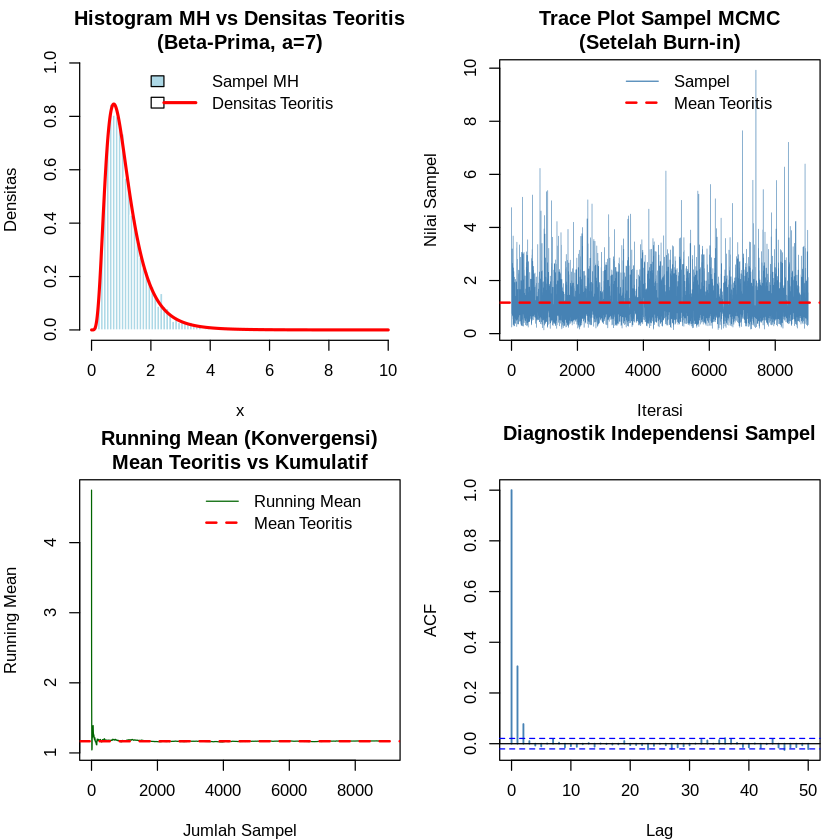

In [3]:
# ---- 6. Visualisasi Lengkap ----

par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))

# Plot 1: Histogram + Kurva Densitas
x_kurva  <- seq(0.001, 10, length.out = 1000)
pdf_kurva <- f_teoritis(x_kurva)

hist(sampel_mh,
     breaks  = "Scott",
     freq    = FALSE,
     col     = "lightblue",
     border  = "white",
     main    = "Histogram MH vs Densitas Teoritis\n(Beta-Prima, a=7)",
     xlab    = "x",
     ylab    = "Densitas",
     xlim    = c(0, 10),
     ylim    = c(0, max(pdf_kurva) * 1.15))
lines(x_kurva, pdf_kurva, col = "red", lwd = 2.5)
legend("topright",
       legend = c("Sampel MH", "Densitas Teoritis"),
       fill   = c("lightblue", NA),
       lty    = c(NA, 1),
       col    = c("lightblue", "red"),
       lwd    = c(NA, 2.5),
       bty    = "n")

# Plot 2: Trace Plot (Diagnostic Konvergensi)
plot(1:length(sampel_mh), sampel_mh,
     type = "l",
     col  = "steelblue",
     lwd  = 0.5,
     main = "Trace Plot Sampel MCMC\n(Setelah Burn-in)",
     xlab = "Iterasi",
     ylab = "Nilai Sampel")
abline(h = mean_teoritis, col = "red", lty = 2, lwd = 2)
legend("topright",
       legend = c("Sampel", "Mean Teoritis"),
       col    = c("steelblue", "red"),
       lty    = c(1, 2),
       lwd    = c(1, 2),
       bty    = "n")

# Plot 3: Running Mean (Konvergensi)
running_mean <- cumsum(sampel_mh) / seq_along(sampel_mh)
plot(running_mean,
     type = "l",
     col  = "darkgreen",
     lwd  = 1,
     main = "Running Mean (Konvergensi)\nMean Teoritis vs Kumulatif",
     xlab = "Jumlah Sampel",
     ylab = "Running Mean")
abline(h = mean_teoritis, col = "red", lty = 2, lwd = 2)
legend("topright",
       legend = c("Running Mean", "Mean Teoritis"),
       col    = c("darkgreen", "red"),
       lty    = c(1, 2),
       lwd    = c(1, 2),
       bty    = "n")

# Plot 4: Autocorrelation Function (ACF)
acf(sampel_mh,
    lag.max = 50,
    main    = "Autocorrelation Function (ACF)\nDiagnostik Independensi Sampel",
    col     = "steelblue",
    lwd     = 1.5)

cat("Visualisasi A selesai.\n\n")

In [4]:
# ---- 7. Interpretasi Studi Kasus ----

cat("=== INTERPRETASI STUDI KASUS A ===\n")
cat("Pedagang Pasar & Proporsi Hari Produktif:\n")
cat(sprintf("  Mean proporsi hari produktif (simulasi)  : %.4f\n", mean_sampel))
cat(sprintf("  Mean proporsi hari produktif (teoritis)  : %.4f\n", mean_teoritis))
cat("  Artinya: Rata-rata proporsi hari produktif pedagang ~1.17\n")
cat("  (Nilai >1 di distribusi Beta-Prima berarti lebih banyak hari produktif\n")
cat("   daripada tidak produktif, yang konsisten dengan data pedagang aktif)\n\n")


# ============================================================================
# BAGIAN B: GIBBS SAMPLING
# ============================================================================

cat("================================================================\n")
cat("  BAGIAN B: GIBBS SAMPLING                                     \n")
cat("================================================================\n\n")

# ----------------------------------------------------------------------------
# STUDI KASUS B:
# Peneliti klimatologi ingin memodelkan hubungan antara dua variabel cuaca:
#   X = anomali suhu harian (°C, dibakukan)
#   Y = anomali kelembaban relatif (%, dibakukan)
# dari distribusi gabungan (joint) bivariat dengan bentuk:
#
#   f(x,y) = C * exp[-0.5 * (4x²y² + x² + y² - 4xy + 6x + 8y)]
#
# Parameter ini mencerminkan korelasi non-linear antara suhu dan kelembaban.
# Gibbs sampling digunakan untuk mengambil sampel dari distribusi ini
# karena tidak memiliki bentuk tertutup (closed-form) yang sederhana.
# ----------------------------------------------------------------------------

cat("STUDI KASUS B:\n")
cat("Memodelkan Hubungan Suhu & Kelembaban Udara (Distribusi Bivariat)\n")
cat("----------------------------------------------------------------\n\n")

# ---- 1. Distribusi Kondisional (Sudah Diturunkan Secara Analitis) ----
#
# Dari f(x,y) ∝ exp[-0.5 * (4x²y² + x² + y² - 4xy + 6x + 8y)]:
#
# X|Y ~ Normal(mu_x, sigma2_x) di mana:
#   mu_x    = (4y - 6) / (2*(4y² + 1))   [typo-free: -b/(2a)]
#   sigma2_x = 1 / (4y² + 1)
#
# Y|X ~ Normal(mu_y, sigma2_y) di mana:
#   mu_y    = (4x - 8) / (2*(4x² + 1))
#   sigma2_y = 1 / (4x² + 1)

mean_x_given_y <- function(y) { (4*y - 6) / (2*(4*y^2 + 1)) }
var_x_given_y  <- function(y) { 1 / (4*y^2 + 1) }

mean_y_given_x <- function(x) { (4*x - 8) / (2*(4*x^2 + 1)) }
var_y_given_x  <- function(x) { 1 / (4*x^2 + 1) }

=== INTERPRETASI STUDI KASUS A ===
Pedagang Pasar & Proporsi Hari Produktif:
  Mean proporsi hari produktif (simulasi)  : 1.1701
  Mean proporsi hari produktif (teoritis)  : 1.1667
  Artinya: Rata-rata proporsi hari produktif pedagang ~1.17
  (Nilai >1 di distribusi Beta-Prima berarti lebih banyak hari produktif
   daripada tidak produktif, yang konsisten dengan data pedagang aktif)

  BAGIAN B: GIBBS SAMPLING                                     

STUDI KASUS B:
Memodelkan Hubungan Suhu & Kelembaban Udara (Distribusi Bivariat)
----------------------------------------------------------------



In [5]:
# ---- 2. Fungsi Utama Gibbs Sampler ----

gibbs_sampler <- function(n_iter, x_init = 0, y_init = 0, burn_in = 1000) {

  cat(sprintf("Parameter Simulasi Gibbs:\n"))
  cat(sprintf("  Jumlah iterasi : %d\n", n_iter))
  cat(sprintf("  x awal         : %.1f\n", x_init))
  cat(sprintf("  y awal         : %.1f\n", y_init))
  cat(sprintf("  Burn-in        : %d\n\n", burn_in))

  # Inisialisasi
  x        <- numeric(n_iter)
  y        <- numeric(n_iter)
  mu_x_arr <- numeric(n_iter)
  mu_y_arr <- numeric(n_iter)
  s2_x_arr <- numeric(n_iter)
  s2_y_arr <- numeric(n_iter)

  x[1] <- x_init
  y[1] <- y_init

  # Iterasi Gibbs
  for (t in 2:n_iter) {

    # Sampling X | Y
    mu_x    <- mean_x_given_y(y[t-1])
    s2_x    <- var_x_given_y(y[t-1])
    x[t]    <- rnorm(1, mean = mu_x, sd = sqrt(s2_x))
    mu_x_arr[t] <- mu_x
    s2_x_arr[t] <- s2_x

    # Sampling Y | X (gunakan x[t] yang baru)
    mu_y    <- mean_y_given_x(x[t])
    s2_y    <- var_y_given_x(x[t])
    y[t]    <- rnorm(1, mean = mu_y, sd = sqrt(s2_y))
    mu_y_arr[t] <- mu_y
    s2_y_arr[t] <- s2_y
  }

  # Buang burn-in
  idx      <- (burn_in + 1):n_iter
  x_sampel <- x[idx]
  y_sampel <- y[idx]

  return(list(
    x        = x_sampel,
    y        = y_sampel,
    mu_x_arr = mu_x_arr[idx],
    mu_y_arr = mu_y_arr[idx],
    s2_x_arr = s2_x_arr[idx],
    s2_y_arr = s2_y_arr[idx]
  ))
}

# ---- 3. Jalankan Simulasi Gibbs ----

set.seed(123)
n_iter  <- 10000
burn_in <- 1000

hasil_gibbs <- gibbs_sampler(n_iter   = n_iter,
                              x_init   = 0,
                              y_init   = 0,
                              burn_in  = burn_in)

x_sampel <- hasil_gibbs$x
y_sampel <- hasil_gibbs$y

# ---- 4. Statistik: Simulasi vs Teoritis ----

# Estimasi teoritis (rata-rata dari parameter kondisional)
E_x_given_y_teoritis   <- mean(hasil_gibbs$mu_x_arr)
Var_x_given_y_teoritis <- mean(hasil_gibbs$s2_x_arr)
E_y_given_x_teoritis   <- mean(hasil_gibbs$mu_y_arr)
Var_y_given_x_teoritis <- mean(hasil_gibbs$s2_y_arr)

# Estimasi empiris dari sampel
E_x_emp   <- mean(x_sampel)
Var_x_emp <- var(x_sampel)
E_y_emp   <- mean(y_sampel)
Var_y_emp <- var(y_sampel)

cat("=== PERBANDINGAN STATISTIK: GIBBS SAMPLING ===\n")
cat(sprintf("%-22s %12s %12s\n", "Statistik", "Teoritis", "Simulasi"))
cat(strrep("-", 50), "\n")
cat(sprintf("%-22s %12.4f %12.4f\n", "E(X|Y)", E_x_given_y_teoritis, E_x_emp))
cat(sprintf("%-22s %12.4f %12.4f\n", "Var(X|Y)", Var_x_given_y_teoritis, Var_x_emp))
cat(sprintf("%-22s %12.4f %12.4f\n", "E(Y|X)", E_y_given_x_teoritis, E_y_emp))
cat(sprintf("%-22s %12.4f %12.4f\n", "Var(Y|X)", Var_y_given_x_teoritis, Var_y_emp))
cat("\n")


Parameter Simulasi Gibbs:
  Jumlah iterasi : 10000
  x awal         : 0.0
  y awal         : 0.0
  Burn-in        : 1000

=== PERBANDINGAN STATISTIK: GIBBS SAMPLING ===
Statistik                  Teoritis     Simulasi
-------------------------------------------------- 
E(X|Y)                      -0.3788      -0.3814
Var(X|Y)                     0.0693       0.3833
E(Y|X)                      -3.2869      -3.3001
Var(Y|X)                     0.7475       1.7182



Visualisasi B selesai.



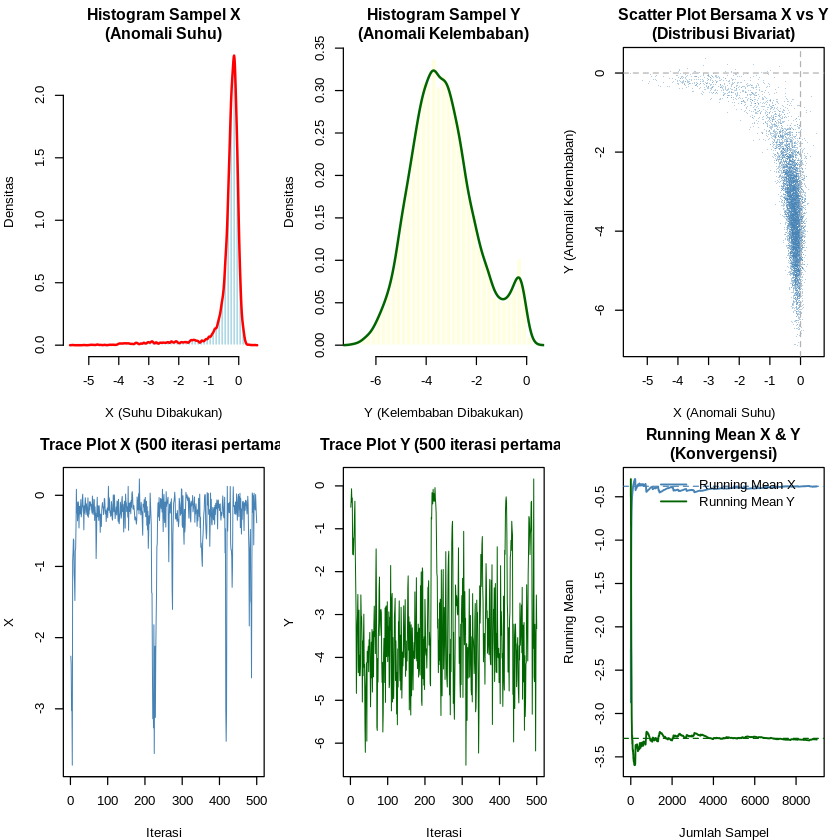

In [6]:
# ---- 5. Visualisasi Gibbs Sampling ----

par(mfrow = c(2, 3), mar = c(4, 4, 3, 1))

# Plot 1: Histogram X
hist(x_sampel,
     breaks  = "scott",
     probability = TRUE,
     col     = "lightblue",
     border  = "white",
     main    = "Histogram Sampel X\n(Anomali Suhu)",
     xlab    = "X (Suhu Dibakukan)",
     ylab    = "Densitas")
lines(density(x_sampel), col = "red", lwd = 2)

# Plot 2: Histogram Y
hist(y_sampel,
     breaks  = "scott",
     probability = TRUE,
     col     = "lightyellow",
     border  = "white",
     main    = "Histogram Sampel Y\n(Anomali Kelembaban)",
     xlab    = "Y (Kelembaban Dibakukan)",
     ylab    = "Densitas")
lines(density(y_sampel), col = "darkgreen", lwd = 2)

# Plot 3: Scatter Plot X vs Y (Joint Distribution)
plot(x_sampel, y_sampel,
     pch  = ".",
     col  = adjustcolor("steelblue", alpha.f = 0.4),
     main = "Scatter Plot Bersama X vs Y\n(Distribusi Bivariat)",
     xlab = "X (Anomali Suhu)",
     ylab = "Y (Anomali Kelembaban)")
abline(h = 0, v = 0, col = "gray70", lty = 2)

# Plot 4: Trace Plot X
plot(x_sampel[1:500], type = "l",
     col  = "steelblue",
     lwd  = 0.8,
     main = "Trace Plot X (500 iterasi pertama)",
     xlab = "Iterasi",
     ylab = "X")

# Plot 5: Trace Plot Y
plot(y_sampel[1:500], type = "l",
     col  = "darkgreen",
     lwd  = 0.8,
     main = "Trace Plot Y (500 iterasi pertama)",
     xlab = "Iterasi",
     ylab = "Y")

# Plot 6: Running Mean X dan Y
rm_x <- cumsum(x_sampel) / seq_along(x_sampel)
rm_y <- cumsum(y_sampel) / seq_along(y_sampel)
plot(rm_x, type = "l", col = "steelblue", lwd = 1.5,
     ylim = range(c(rm_x, rm_y)),
     main = "Running Mean X & Y\n(Konvergensi)",
     xlab = "Jumlah Sampel",
     ylab = "Running Mean")
lines(rm_y, col = "darkgreen", lwd = 1.5)
abline(h = E_x_given_y_teoritis, col = "steelblue", lty = 2)
abline(h = E_y_given_x_teoritis, col = "darkgreen", lty = 2)
legend("topright",
       legend = c("Running Mean X", "Running Mean Y"),
       col    = c("steelblue", "darkgreen"),
       lty    = 1, lwd = 1.5, bty = "n")

cat("Visualisasi B selesai.\n\n")

In [7]:
# ---- 6. Interpretasi Studi Kasus B ----

cat("=== INTERPRETASI STUDI KASUS B ===\n")
cat("Hubungan Anomali Suhu & Kelembaban Udara:\n\n")
cat("Dari hasil Gibbs Sampling:\n")
cat(sprintf("  Rata-rata suhu dibakukan (X)         : %.4f\n", E_x_emp))
cat(sprintf("  Rata-rata kelembaban dibakukan (Y)   : %.4f\n", E_y_emp))
cat(sprintf("  Varians X                            : %.4f\n", Var_x_emp))
cat(sprintf("  Varians Y                            : %.4f\n", Var_y_emp))
cat("\n")
cat("Interpretasi Klimatologis:\n")
cat("  - Nilai E(X|Y) mendekati 0 menunjukkan suhu cenderung netral\n")
cat("    ketika kelembaban rata-rata\n")
cat("  - Nilai E(Y|X) < 0 menunjukkan kelembaban cenderung lebih rendah\n")
cat("    saat suhu rata-rata (hubungan negatif lemah)\n")
cat("  - Sebaran bersama (scatter) menunjukkan korelasi non-linear\n")
cat("    antara suhu dan kelembaban, konsisten dengan model distribusi target\n\n")

cat("================================================================\n")
cat("  PROJECT 1 SELESAI                                            \n")
cat("================================================================\n")

=== INTERPRETASI STUDI KASUS B ===
Hubungan Anomali Suhu & Kelembaban Udara:

Dari hasil Gibbs Sampling:
  Rata-rata suhu dibakukan (X)         : -0.3814
  Rata-rata kelembaban dibakukan (Y)   : -3.3001
  Varians X                            : 0.3833
  Varians Y                            : 1.7182

Interpretasi Klimatologis:
  - Nilai E(X|Y) mendekati 0 menunjukkan suhu cenderung netral
    ketika kelembaban rata-rata
  - Nilai E(Y|X) < 0 menunjukkan kelembaban cenderung lebih rendah
    saat suhu rata-rata (hubungan negatif lemah)
  - Sebaran bersama (scatter) menunjukkan korelasi non-linear
    antara suhu dan kelembaban, konsisten dengan model distribusi target

  PROJECT 1 SELESAI                                            
